# Superstore Data Analysis

## Summary

Sales is considered one of the most crucial determinants of superstores' performance and profitability, as they can reveal high-value insights about businesses' operations, helping identify deviations and correcting them to support data driven decisions and reach predefined goals.

This report presents a sales data analysis for a superstore operating in the United States, selling Furniture, Office Supplies and technology products to across 48 states + Washington, D.C (missing Alaska and Hawaii). The dataset contains information on sales, ordering and shipping Dates, categories and sub categories, geographic location, shipping modes and other relevant id/names for orderes made between 2015 and 2018. 

analysis shows significant seasonal drops in sales each january, February which are the two months following the highest seasonal spikes in November, December.This pattern can be associated with increased spending in holiday season followed by post-holiday spending meditation. that comes alongside an overall increasing trend over time, esepicially when top states in slaes becoming below mean in january and February. Sales breakdown by category shows relatively similar sales volumes across categories. However, the top sub-categories by sales are phones, chairs, storage, tables and binders, and orders are more often made from NYC, LA and seattle. Furthermore, Consumer segment is the top in slaes Accounting for more than 50% of sales volume.

deeper analysis of shipping duration by shipping mode reveals valuable insights as some same-day orders taking up to 1 day in some states like Arizona, California, Colorado, North Calorina, Texas and Washington.Contrariwise, First class orders taking less than one day in states like New Mexico, Lowa and New Hampshire. while other orders taking up to 4 days in Ohio. This pattern appears in second and standard classes with shipping durations reaching up to five to seven days in some states, while remaining shorter in others.

A big limitation to this analysis is the unavalibility of costs data which limits the analysis' capabilities of matching findings with profitability and makes the sales breakdown charts less Unhelpful for the business. However, shipping delay analysis and seasonal patterns investigation offer Valuable inforamtion that will help this superstore adapt to seasonal variations in sales and improve clients contentment by reducing shipping delays and matching it to the class hierarchy.



## Analysis

### Preparing the Data

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 12,          # Base font size
    'axes.labelsize': 14,     # X and Y axis labels
    'axes.titlesize': 16,     # Plot title
    'xtick.labelsize': 11,    # X-axis tick marks
    'ytick.labelsize': 11,    # Y-axis tick marks
    'legend.fontsize': 11     # Legend text
})
from datetime import date, datetime
data = pd.read_csv('superstore_final_dataset.csv', encoding='latin1' , parse_dates = ['Order_Date' , 'Ship_Date' ])
data['Order_Date'] = pd.to_datetime(data['Order_Date'], dayfirst=True)
data['Ship_Date'] = pd.to_datetime(data['Ship_Date'], dayfirst=True)
data = data.astype({
    'Ship_Mode': 'category',
    'Category': 'category',
    'Sub_Category': 'category',
    'Region': 'category',
    'State': 'category',
    'City': 'category',
    'Product_Name': 'category',
    'Country':'category',
    'Segment':'category'
})

This block of code imports the needed libraries, reads the data and converts each variable to the right type.

### Data at a Glance

In [2]:
print(data.shape)
data['Order_Date' ].describe()

(9800, 18)


count                          9800
mean     2017-05-01 05:13:51.673469
min             2015-01-03 00:00:00
25%             2016-05-24 00:00:00
50%             2017-06-26 00:00:00
75%             2018-05-15 00:00:00
max             2018-12-30 00:00:00
Name: Order_Date, dtype: object

The data contains 18 variables for 9800 product transactions made between 2015-01-03 and 2018-12-30 , with 50% of the transactions made in the period after 2017-06-26 and 25% made after 2018-05-15, this pattern could indicate an upward trend of transactions frequency overtime.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9800 non-null   int64         
 1   Order_ID       9800 non-null   str           
 2   Order_Date     9800 non-null   datetime64[us]
 3   Ship_Date      9800 non-null   datetime64[us]
 4   Ship_Mode      9800 non-null   category      
 5   Customer_ID    9800 non-null   str           
 6   Customer_Name  9800 non-null   str           
 7   Segment        9800 non-null   category      
 8   Country        9800 non-null   category      
 9   City           9800 non-null   category      
 10  State          9800 non-null   category      
 11  Postal_Code    9789 non-null   float64       
 12  Region         9800 non-null   category      
 13  Product_ID     9800 non-null   str           
 14  Category       9800 non-null   category      
 15  Sub_Category   9800 non-null   c

All variables were converted to the right type. The dataset have 11 missing values all in Postal code column so it's not harmful to keep them as we're not using postal code in any of our analysis sections and there're no missing values detected in any other column. Memory usage was reduced from 1.3 MB to 813.7 KB after using categorical variables instead of string variables, Such optimization can make a difference in larger datasets.

In [4]:
data.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


This is a general overview of how the values were recorded in the dataset.

In [5]:
data.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales
count,9800.000000,9800,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2017-05-05 04:17:52.653061,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32041.223413,626.651875


### Sales Trend

Text(0.5, 1.0, 'Sales by Order Date')

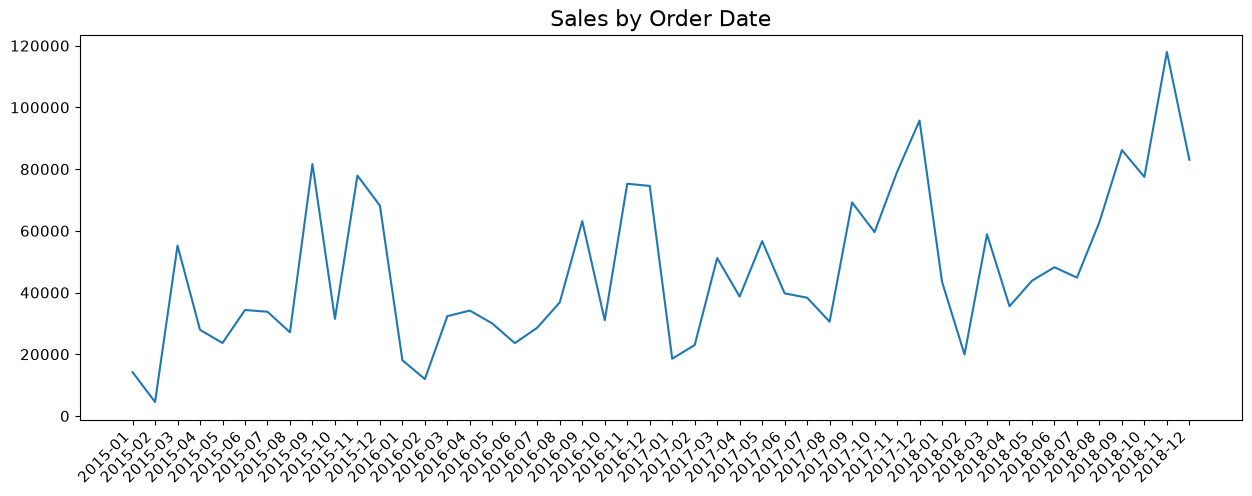

In [6]:
plt.figure(figsize=(15, 5))
monthly_data = data['Sales'].groupby(data['Order_Date'].dt.to_period('M')).sum()
monthly_data.index = monthly_data.index.astype(str)
plt.xticks(rotation=45 , ha='right')
plt.plot(monthly_data.index,monthly_data.values )
plt.title('Sales by Order Date')

The monthly sales data over time shows an upward trend, with huge spikes at the end of each year followed by significant drops at the beginning of the next year. This seasonal pattern may be driven by multiple factors, which will be further analyzed in the seasonal pattern investigation section.

<Axes: xlabel='Day_Name'>

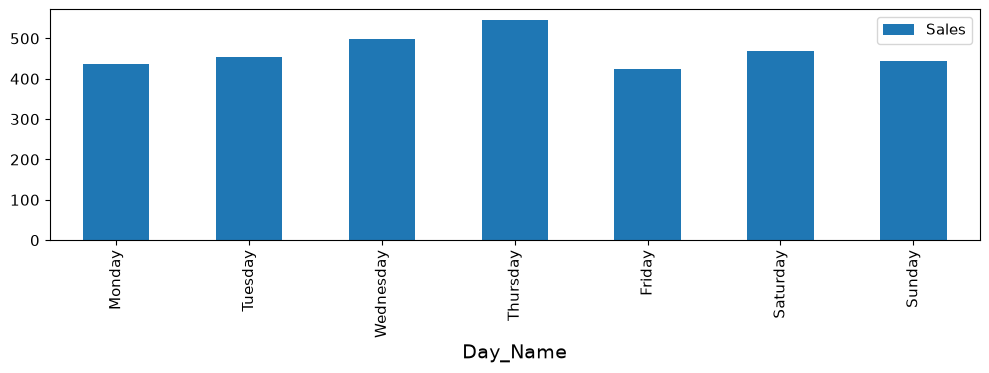

In [7]:
orders_data = data[['State' , 'Order_ID']].groupby('Order_ID').first().reset_index()
orders_data['Ship_Mode'] = (data[['Ship_Mode' , 'Order_ID']].groupby('Order_ID').first().reset_index())['Ship_Mode']
orders_data['Order_Date'] = (data[['Order_Date' , 'Order_ID']].groupby('Order_ID').first().reset_index())['Order_Date']
orders_data['Sales'] = (data[['Sales' ,'Order_ID']].groupby('Order_ID').sum().reset_index())['Sales']

orders_data['Day_Name'] = orders_data['Order_Date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_data['Day_Name'] = pd.Categorical(orders_data['Day_Name'], categories=days_order, ordered=True)
orders_data[['Sales' , 'Day_Name' ]].groupby('Day_Name').mean().plot(kind="bar" , figsize = (12,3) , layout= "compressed" )

### Sales Breakdown

Text(0.5, 1.0, 'Top Months in Sales')

<Figure size 700x700 with 0 Axes>

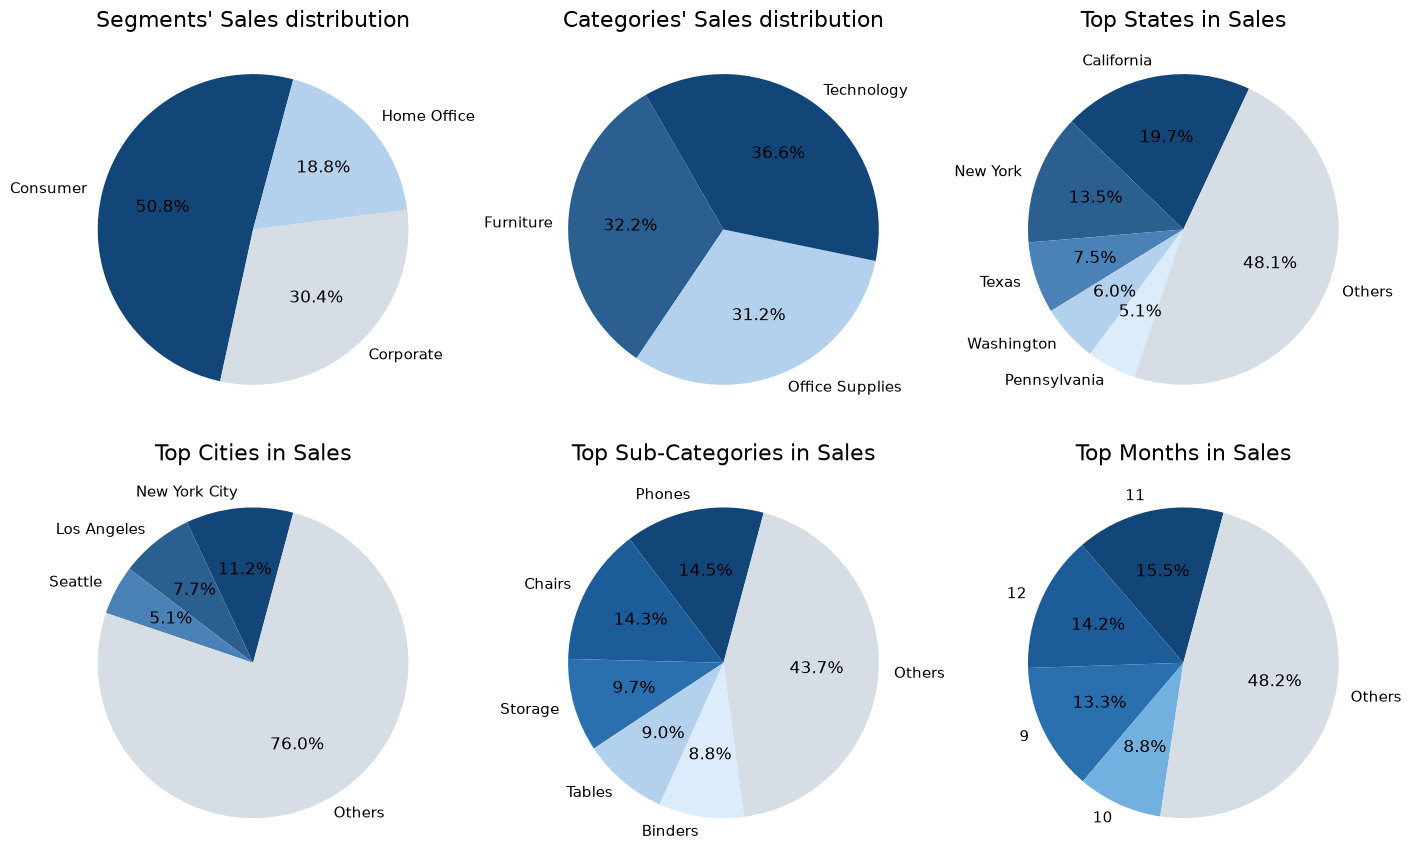

In [8]:
data_by_segment = data.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(7,7))
fig = plt.figure(figsize=(14, 14) , layout= "compressed")
ax1 = fig.add_subplot(3, 3, 1) 
ax1.pie(data_by_segment.values ,autopct='%1.1f%%' ,labels = data_by_segment.index ,  colors = ['#124679', '#d6dde5', '#b3d0ec', '#d6dde5', '#b3d0ec', '#d6dde5', '#e5e8eb', '#f3f4f6'],
    startangle=75)
ax1.set_title('Segments\' Sales distribution')
ax2 = fig.add_subplot(3, 3, 2)
data_by_category = data.groupby('Category')['Sales'].sum()
ax2.pie(data_by_category.values ,labels = data_by_category.index , autopct='%1.1f%%' , colors =['#2b5f8f','#b3d0ec',  '#124679', '#d6dde5', '#b3d0ec', '#d6dde5', '#e5e8eb', '#f3f4f6'],
    startangle=120)
ax2.set_title('Categories\' Sales distribution')
ax3 = fig.add_subplot(3, 3, 3)
top_States = data.groupby('State')['Sales'].sum().sort_values( ascending=False)

top_States = pd.concat([
    top_States.head(5) ,
    pd.Series({'Others' : top_States.iloc[5:].sum()})])

ax3.pie(
   top_States.values,
    labels=top_States.index,
    autopct='%1.1f%%' ,
    colors = ['#124679', '#2b5f8f', '#4a82b8', '#b3d0ec','#dcecfb',  '#d6dde5', '#e5e8eb', '#f3f4f6'],
    
    startangle=65
)
ax3.set_title('Top States in Sales')
ax4 = fig.add_subplot(3, 3, 4)
top_cities = data.groupby('City')['Sales'].sum().sort_values( ascending=False)

top_cities = pd.concat([
    top_cities.head(3) ,
    pd.Series({'Others' : top_cities.iloc[3:].sum()})])

ax4.pie(
   top_cities.values,
    labels=top_cities.index,
    autopct='%1.1f%%' ,
    colors = ['#124679', '#2b5f8f', '#4a82b8', '#d6dde5', '#b3d0ec', '#d6dde5', '#e5e8eb', '#f3f4f6'] ,
    startangle=75
)
ax4.set_title('Top Cities in Sales')

ax5 = fig.add_subplot(3, 3, 5)
top_sales = (
    data.groupby('Sub_Category')['Sales']
        .sum()
        .sort_values(ascending=False)
)

final_df = pd.concat([
    top_sales.head(5),
    pd.Series(
        {'Others': top_sales.iloc[5:].sum()}
    )
])

ax5.pie(
    final_df.values,
    labels=final_df.index,
    autopct='%1.1f%%',
    colors = ['#124679', '#1c5c99', '#2a70af', '#b3d0ec','#dcecfb', '#d6dde5', '#dcecfb', '#eef6fd'],
    startangle=75
)
ax5.set_title('Top Sub-Categories in Sales')
ax6 = fig.add_subplot(3, 3, 6)
top_months = (
    data.groupby(data['Order_Date'].dt.month)['Sales']
        .sum()
        .sort_values(ascending=False)
)

final_df = pd.concat([
    top_months.head(4),
    pd.Series(
        {'Others': top_months.iloc[4:].sum()}
    )
])

ax6.pie(
    final_df.values,
    labels=final_df.index,
    autopct='%1.1f%%',
    colors = ['#124679', '#1c5c99', '#2a70af', '#72b0e0', '#d6dde5', '#d6dde5', '#dcecfb', '#eef6fd'],
    startangle=75)
ax6.set_title('Top Months in Sales')

Sales breakdown by segment reveals that the Consumer market leads with 50.8% of total sales, followed by the Corporate sector at 30.4%, while the Home Office segment accounts for the remaining 18.8%. The sales breakdown by category shows a balanced distribution across the three categories: Technology, Furniture, and Office Supplies. However, sales are concentrated in five sub-categories: Phones, Chairs, Storage, Tables, and Binders. Sales are highly concentrated geographically, with California, New York, Texas, Washington, and Pennsylvania collectively accounting for over half of total sakes, while the remaining 44 states account for the rest. Moreover, the top three cities by sales are New York City, Los Angeles, and Seattle

### Shipping Delay Analysis.

In [9]:
data['shipping_delay'] = data['Ship_Date'] - data['Order_Date']

orders_data['shipping_delay'] = (data[['shipping_delay' ,'Order_ID']].groupby('Order_ID').first().reset_index())['shipping_delay']

data['shipping_delay_days'] = data['shipping_delay'].dt.total_seconds() / (24 * 3600)

orders_data['shipping_delay_days'] = (data[['shipping_delay_days' , 'Order_ID']].groupby('Order_ID').first().reset_index())['shipping_delay_days']


average order is being shipped  after almost 4 days of ordering, some orders are taking up to 7 days to be shipped while others being shipped in the same day.

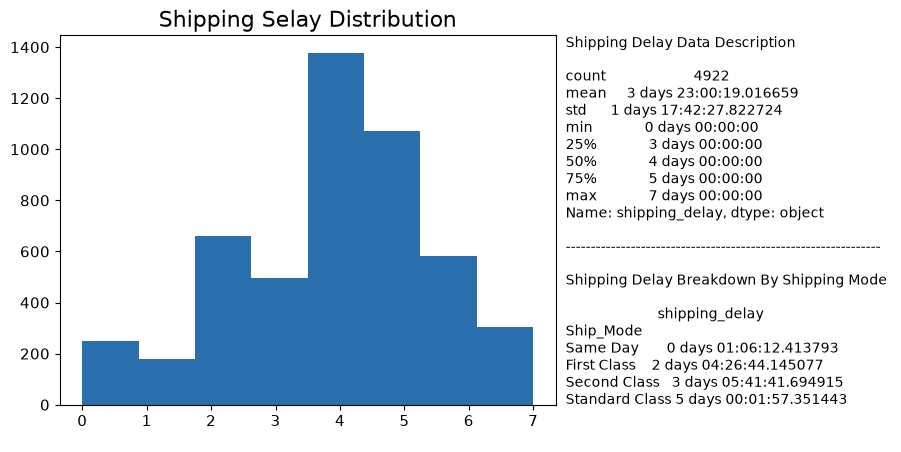

In [10]:
fig, ax = plt.subplots()
ax.hist(orders_data['shipping_delay'].dt.days.astype('int64') ,  color = '#2a70af' , bins = 8 )

shippingDelay_shipMode_data = orders_data[['shipping_delay' , 'Ship_Mode']].groupby('Ship_Mode').mean()
sorteddata = shippingDelay_shipMode_data.sort_values(by = 'shipping_delay' )

result = ( f"Shipping Delay Data Description \n\n{orders_data['shipping_delay'].describe()}\n\n"
           f"---------------------------------------------------------------\n\n"
    f"Shipping Delay Breakdown By Shipping Mode \n\n{sorteddata.to_string()}\n\n"
  )

ax.text(1.02, 0.45, result ,
        transform=ax.transAxes, 
        verticalalignment='center', 
        horizontalalignment='left',
        fontsize=10, 
        color='black')

ax.set_title('Shipping Selay Distribution')
plt.show()

Shipping Delay distribution shows that most orders takes 4 to 5 days until shipping.

Shipping delay between consecutive shipping modes vary. with same-day mode orders taking more than one day sometimes but averaged at 1 hour while first class taking slightly more than 2 days in average and Second class taking slightly more than 3 days. finally, Standard class taking around 5 days on average.

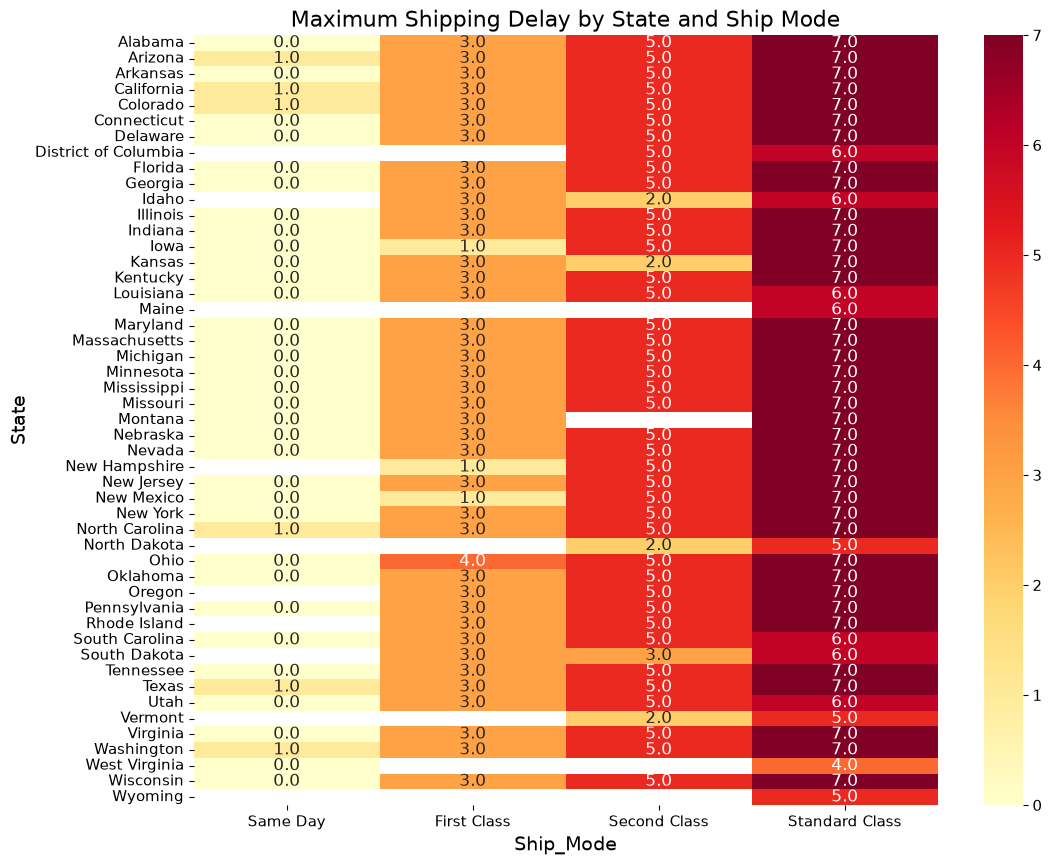

In [11]:

geoDelay_data = orders_data[['shipping_delay_days' , 'Ship_Mode','State']].groupby(['State', 'Ship_Mode']).max().reset_index()
pivot = geoDelay_data.pivot(
    index='State',
    columns='Ship_Mode',
    values='shipping_delay_days'
)

pivot = pivot[
    ['Same Day', 'First Class', 'Second Class', 'Standard Class']
]

plt.figure(figsize=(12,10))

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f'
)

plt.title('Maximum Shipping Delay by State and Ship Mode')
plt.show()

This heat-map shows insightful information about shipping delay deviations across states and modes. First of all, Same-Day mode taking up to one day in some states like Washington, North Carolina, Colorado, California and Arizona which indicate some shipping problems in these states that should be invistigated more for diviation correction. for a first class orders, most states have thier orders shipped in no more than 3 days and sometimes in just 1 day except for Ohio whose orders are taking up to 4 days in shipping. Moreover, Second-Class orders taking less than 2 days in some states which is less than some First-Class orders shipping duration. Standard-Class orders doesn't show much of an insights other than West Virginia whose orders taking less than 4 days for shipping which is also less than some orders in the lower Firt-class mode. Consequently , same-day orders should be shipped in the same day other than maybe some late night orders if available, this potential problem needs more data to be investigated further. Moreover, it's good to have some states' second class and standard class orders shipping in less than the expected duration but it will be better to copy some mechanisims to improve other states' shipping delay.

### Seasonal Pattern Investigation

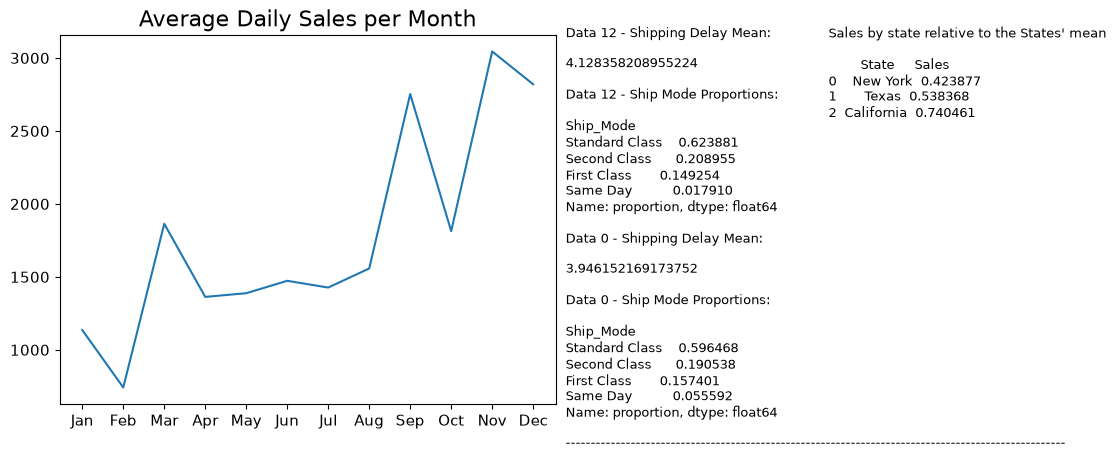

In [12]:

data_12 = orders_data[orders_data['Order_Date'].dt.month <= 2]
data_0 = orders_data[orders_data['Order_Date'].dt.month > 2]


daily_data = data[[ 'Sales' , 'Order_Date']].groupby('Order_Date').sum().reset_index()
daily_data['Order_Month'] = daily_data['Order_Date'].dt.month

data_by_month = daily_data[[ 'Sales' , 'Order_Month']].groupby('Order_Month').mean().reset_index()
data_by_month.sort_values(by = 'Sales')

fig, ax = plt.subplots()
ax.plot(data_by_month['Order_Month'] , data_by_month['Sales'] )
ax.set_xticks(data_by_month['Order_Month'] , ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_title('Average Daily Sales per Month')

dt = data_12[['Sales' , 'State']].groupby('State').mean().sort_values(by = 'Sales')
dt['Sales'] /= data_12[['Sales' , 'State']].groupby('State').mean().mean()['Sales']

state_table = dt.loc[['New York' , 'Texas', 'California']].reset_index()
divide = "-" * 100
result1 = (
    f"Data 12 - Shipping Delay Mean: \n\n{data_12['shipping_delay_days'].mean()}\n\n"
    f"Data 12 - Ship Mode Proportions:\n\n{data_12['Ship_Mode'].value_counts(normalize=True)}\n\n"
    f"Data 0 - Shipping Delay Mean: \n\n{data_0['shipping_delay_days'].mean()}\n\n"
    f"Data 0 - Ship Mode Proportions:\n\n{data_0['Ship_Mode'].value_counts(normalize=True)}\n\n"
       f"{divide}"
)
result2 = ( f"Sales by state relative to the States' mean \n\n{state_table.to_string()}\n\n" )

ax.text(1.02, 0.45,result1 , 
        transform=ax.transAxes, 
        verticalalignment='center', 
        horizontalalignment='left',
        fontsize=9, 
        color='black')

ax.text(1.55 ,0.855,result2 , 
        transform=ax.transAxes, 
        verticalalignment='center', 
        horizontalalignment='left',
        fontsize=9, 
        color='black')

plt.show()

This line chart Further supports the seasonal pattern mentioned before, as daily sales decreases a lot in january and february after spiking in november and december , this pattern is mostly caused by behavioral reasons as consumers increase spending in holiday seasons then they follows it by Spending Retrenchment for the purpose of paying off debt or because of overspending feeling. However, additional data would be required to confirm the drivers of this pattern.

This data shows a slightly more shipping delay in january and february compared to other months fully justifies by some orders shifting from same-day mode to lower class modes which may reinforces the previous hypotheses of Spending Retrenchment.

top 3 states in sales around the year are less than average in sales in january and february.